### Angel Xavier
#### RollNo. 01
#### SE-AIML
#### Date: 18/03/2026

# Experiment 9: Apply PCA and LDA to reduce dataset dimensions

### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

### Load Dataset

In [6]:
iris = datasets.load_iris()
x=iris.data
y=iris.target

features_names=iris.feature_names
print("Features:",iris.feature_names)
print("Class:",iris.target_names)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Class: ['setosa' 'versicolor' 'virginica']


### Dataset Summary

In [11]:
print("----Dataset Summary----")
print("Number of Samples:",x.shape[0])
print("Number of features:",x.shape[1])
print("Number of Classes:",len(np.unique(y)))
print(features_names)

----Dataset Summary----
Number of Samples: 150
Number of features: 4
Number of Classes: 3
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


### Feature Stats before PCA

In [12]:
df=pd.DataFrame(x, columns=features_names)

print("FEATURE STATISTICS")
stat_table=pd.DataFrame({
    "Mean": df.mean(),
    "Standard Deviation": df.std()
})

print(stat_table)
print()
print(df.head())
print()

FEATURE STATISTICS
                       Mean  Standard Deviation
sepal length (cm)  5.843333            0.828066
sepal width (cm)   3.057333            0.435866
petal length (cm)  3.758000            1.765298
petal width (cm)   1.199333            0.762238

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2



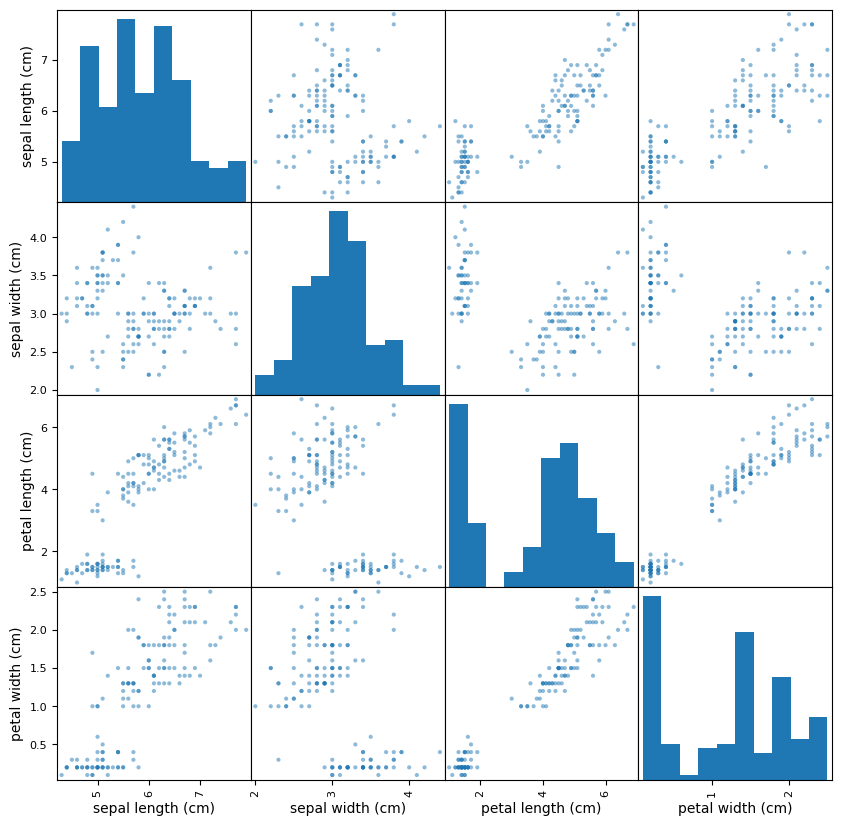

In [13]:
pd.plotting.scatter_matrix(
    df.iloc[:,0:4],
    figsize=(10,10),
    diagonal='hist'
)

plt.show()

## PCA

In [14]:
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

In [18]:
pca=PCA(n_components=1)
x_pca=pca.fit_transform(x_scaled)

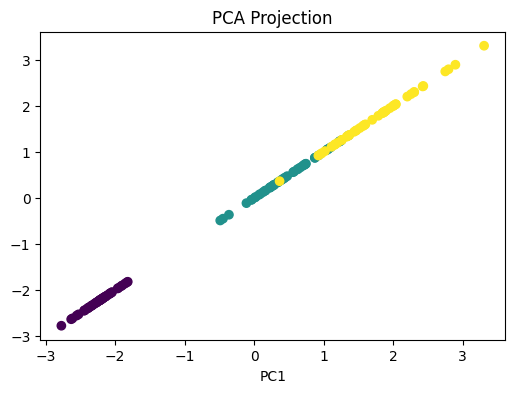

In [25]:
plt.figure(figsize=(6,4))
plt.scatter(x_pca[:,0],x_pca[:,0],c=y)
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.show()

In [26]:
explained_variance=pca.explained_variance_
variance_ratio=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(variance_ratio)

In [27]:
pca_table=pd.DataFrame({
    "Eigenvalue": explained_variance,
    "Explaind Variance (%)": variance_ratio*100,
    "Cumulative Variance (%)": cumulative_variance*100
})

print("PCA VARIANCE TABLE")
print(pca_table)
print()

PCA VARIANCE TABLE
   Eigenvalue  Explaind Variance (%)  Cumulative Variance (%)
0    2.938085              72.962445                72.962445



## LDA

In [32]:
lda=LinearDiscriminantAnalysis(n_components=1)
x_lda=lda.fit_transform(x_scaled, y)

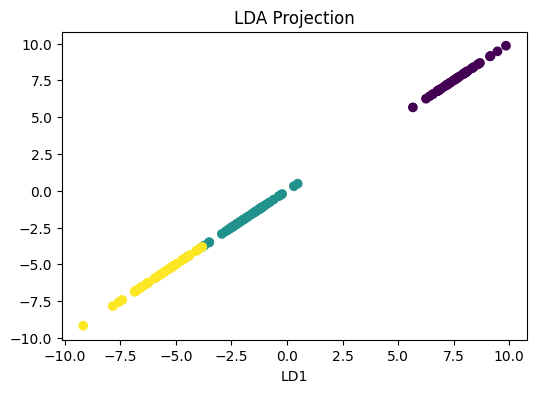

In [47]:
plt.figure(figsize=(6,4))
plt.scatter(x_lda[:,0],x_lda[:,0],c=y)
plt.title("LDA Projection")
plt.xlabel("LD1")
plt.show()

In [48]:
x_train, x_test, y_train, y_test=train_test_split(x_scaled, y , test_size=0.3, random_state=42)

In [49]:
xp_train, xp_test, yp_train, yp_test=train_test_split(x_pca, y , test_size=0.3, random_state=42)

In [50]:
xl_train, xl_test, yl_train, yl_test=train_test_split(x_lda, y , test_size=0.3, random_state=42)

In [51]:
model=KNeighborsClassifier()

#Original Data
start=time.time()
model.fit(x_train,y_train)
train_time_original=time.time()-start

y_pred=model.predict(x_test)
acc_original=accuracy_score(y_test, y_pred)

#PCA Data
start=time.time()
model.fit(xp_train,yp_train)
train_time_pca=time.time()-start

y_pred=model.predict(xp_test)
acc_pca=accuracy_score(yp_test, y_pred)

#LDA Data
start=time.time()
model.fit(xl_train,yl_train)
train_time_lda=time.time()-start

y_pred=model.predict(xl_test)
acc_lda=accuracy_score(yl_test, y_pred)

In [52]:
accuracy_table=pd.DataFrame({
    "Dataset ":["Original", "PCA Reduced","LDA Reduced"],
    "Accuracy": [acc_original, acc_pca, acc_lda],
    "Train Time ":[train_time_original, train_time_pca, train_time_lda]
})
print("-----Performance Table-----")

print(accuracy_table)

-----Performance Table-----
      Dataset   Accuracy  Train Time 
0     Original  1.000000     0.005992
1  PCA Reduced  0.911111     0.001000
2  LDA Reduced  1.000000     0.000983
